In [1]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [23]:
from sklearn.tree import export_graphviz
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score

In [3]:
Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

### Instanciando o classificador

In [4]:
dt_classificador = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)

In [5]:
dt_classificador.fit(Xtrain, Ytrain)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
"""export_graphviz(
    dt_classificador,
    out_file= "../results/decision_tree.dot",
    #feature_names=Xtest.columns,
    #class_names='',
    rounded=True,
    filled=True
)"""

In [19]:
y_train_pred_cv = cross_val_predict(dt_classificador, Xtrain, Ytrain, cv=3)

In [26]:
cross_val_score(dt_classificador, Xtrain, Ytrain, cv=3).round(4)

array([0.931 , 0.9248, 0.9199])

In [12]:
precision_score(Ytrain, y_train_pred_cv,  average='weighted')

0.9243143547066797

In [13]:
recall_score(Ytrain, y_train_pred_cv, labels = dt_classificador.classes_, average= 'weighted')

0.9252483010977522

In [15]:
ypredict = dt_classificador.predict(Xtest)

In [16]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report

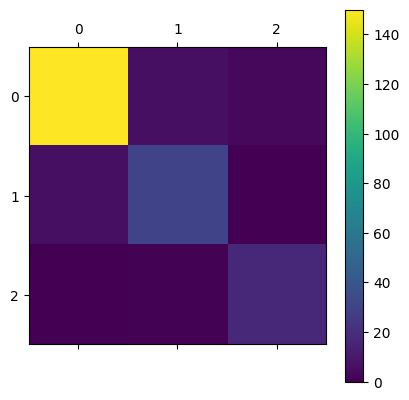

<Figure size 800x600 with 0 Axes>

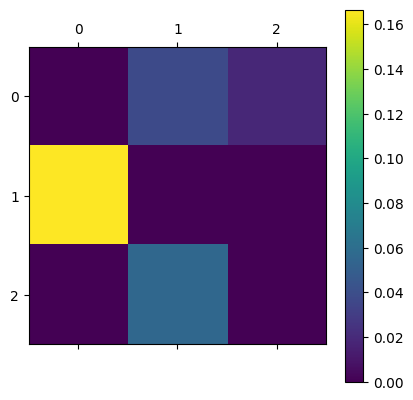

In [17]:
conf_mx = confusion_matrix(Ytest, ypredict)

plt.matshow(conf_mx)
plt.colorbar()
plt.savefig('../results/ConfMatrixDecisionTree.png')
plt.show()

row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums
np.fill_diagonal(norm_conf_mx, 0)
plt.figure(figsize=(8,6))
plt.matshow(norm_conf_mx)
plt.colorbar()
plt.savefig('../results/relativeConfDecisionTree.png')
plt.show()

In [28]:
fresults = open('../results/classificationMetricsDecisionTree.png', 'w+')
fresults.write(classification_report(Ytest, ypredict))
print(classification_report(Ytest, ypredict))

fresults.close()

              precision    recall  f1-score   support

           1       0.96      0.94      0.95       159
           2       0.81      0.83      0.82        36
           3       0.85      0.94      0.89        18

    accuracy                           0.92       213
   macro avg       0.87      0.91      0.89       213
weighted avg       0.93      0.92      0.93       213

